In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import load_img, img_to_array
from scipy.signal import convolve2d
from PIL import Image

2024-05-29 15:40:14.869026: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


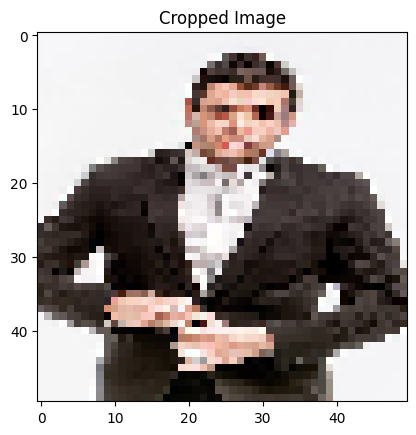

In [2]:
# Load and preprocess the cropped image
croppedImagePath = 'oneofthecoats.jpeg'
imgCropped = load_img(croppedImagePath, target_size=(50, 50))
imgArrayCropped = img_to_array(imgCropped) / 255.0

# Display the cropped image
plt.imshow(imgArrayCropped)
plt.title("Cropped Image")
plt.show()

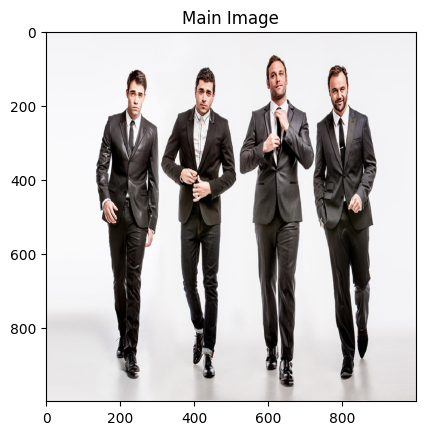

In [3]:
# Load and preprocess the main image
imagePath = 'thecoats.jpeg'
imgMain = load_img(imagePath, target_size=(1000, 1000))
imgArrayMain = img_to_array(imgMain) / 255.0

# Display the main image
plt.imshow(imgArrayMain)
plt.title("Main Image")
plt.show()

In [4]:
# Convert the images to grayscale for convolution using Pillow
imgCroppedGray = Image.fromarray((imgArrayCropped * 255).astype(np.uint8)).convert('L')
imgArrayCroppedGray = np.array(imgCroppedGray)/255

imgMainGray = Image.fromarray((imgArrayMain * 255).astype(np.uint8)).convert('L')
imgArrayMainGray = np.array(imgMainGray)/255

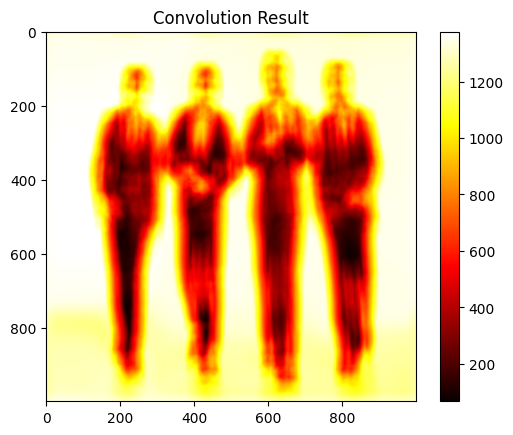

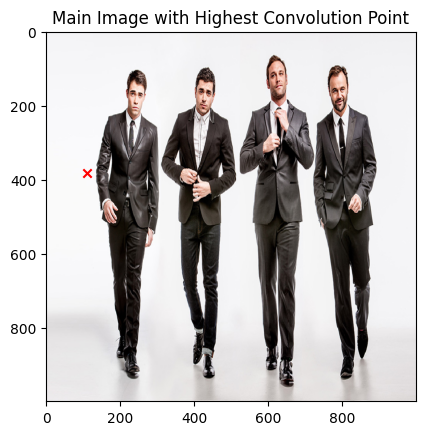

In [5]:
# Perform convolution using scipy.signal.convolve2d
convolutionResult = convolve2d(imgArrayMainGray, imgArrayCroppedGray, mode='same', boundary='wrap')
# Find the coordinates of the maximum value in the convolution result
max_y, max_x = np.unravel_index(np.argmax(convolutionResult), convolutionResult.shape)

# Display the convolution result
plt.imshow(convolutionResult, cmap='hot')
plt.colorbar()
plt.title("Convolution Result")
plt.show()

# Display the main image with a marker at the highest convolution point
plt.imshow(imgArrayMain)
plt.scatter([max_x], [max_y], color='red', marker='x')
plt.title("Main Image with Highest Convolution Point")
plt.show()